In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

In [3]:
folder_path = "data"
df = pd.DataFrame()

for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    if os.path.isfile(file_path) and filename.endswith('.par'):
        temp_df = pd.read_parquet(file_path)
        df = pd.concat([df, temp_df], ignore_index=True)


In [4]:
df.columns

Index(['symbol', 'RV21', 'RV63', 'VolRatio3_21', 'VolRatio5_63', 'DolVol_21',
       'timestamp', 'expiry_0', 'strike_0', 'type_0', 'implied_vol_0',
       'delta_0', 'option_price_0', 'pv_dividend_0', 'gamma_0', 'vega_0',
       'theta_0', 'underlying_price_0', 'expiry_1', 'strike_1', 'type_1',
       'implied_vol_1', 'delta_1', 'option_price_1', 'pv_dividend_1',
       'gamma_1', 'vega_1', 'theta_1', 'underlying_price_1', 'expiry_2',
       'strike_2', 'type_2', 'implied_vol_2', 'delta_2', 'option_price_2',
       'pv_dividend_2', 'gamma_2', 'vega_2', 'theta_2', 'underlying_price_2',
       'expiry_3', 'strike_3', 'type_3', 'implied_vol_3', 'delta_3',
       'option_price_3', 'pv_dividend_3', 'gamma_3', 'vega_3', 'theta_3',
       'underlying_price_3', 'day1_timestamp', 'day1_expiry_0',
       'day1_strike_0', 'day1_type_0', 'day1_implied_vol_0', 'day1_delta_0',
       'day1_option_price_0', 'day1_pv_dividend_0', 'day1_gamma_0',
       'day1_vega_0', 'day1_theta_0', 'day1_underlying_

# Setting Expiry Values to Midnight

In [5]:
df = df.assign(**{
    col: pd.to_datetime(df[col]).dt.tz_localize(None).dt.normalize() + pd.Timedelta(hours=23, minutes=59, seconds=59)
    for col in df.filter(regex='expiry', axis=1)
})

df = df.assign(**{
    col: pd.to_datetime(df[col]).dt.tz_localize(None)
    for col in df.filter(regex='timestamp', axis=1)
})


In [6]:
df[["timestamp","expiry_0","day1_timestamp", "day1_expiry_0", "day1_expiry_1"]]

,timestamp,expiry_0,day1_timestamp,day1_expiry_0,day1_expiry_1
0,2025-02-27 18:22:36.210411,2025-03-21 23:59:59,2025-02-28 14:55:37.568793,2025-03-21 23:59:59,NaT
1,2025-02-27 18:22:48.113577,2025-02-28 23:59:59,2025-02-28 14:55:50.174505,2025-02-28 23:59:59,2025-03-07 23:59:59
2,2025-02-27 18:23:01.146576,2025-02-28 23:59:59,2025-02-28 14:56:02.165634,2025-02-28 23:59:59,2025-03-07 23:59:59
3,2025-02-27 18:23:04.219848,2025-03-21 23:59:59,2025-02-28 14:56:06.002325,2025-03-21 23:59:59,NaT
4,2025-02-27 18:23:08.087857,2025-03-21 23:59:59,2025-02-28 14:56:08.158199,2025-03-21 23:59:59,NaT
...,...,...,...,...,...
156,2025-03-10 16:49:56.120325,2025-03-21 23:59:59,2025-03-12 18:28:41.076928,2025-03-21 23:59:59,NaT
157,2025-03-10 16:50:00.003799,2025-03-21 23:59:59,2025-03-12 18:28:43.103464,2025-03-21 23:59:59,NaT
158,2025-03-10 16:50:10.799865,2025-03-14 23:59:59,2025-03-12 18:28:55.077315,2025-03-14 23:59:59,2025-03-21 23:59:59
159,NaT,NaT,NaT,NaT,NaT


## Black-Scholes Model for Call Options

In [7]:
import numpy as np
from scipy.stats import norm
import warnings

warnings.filterwarnings("ignore")

# Constants
r = 0.044

# Black-Scholes Call Option Formula
def black_scholes_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Function to apply to a single DataFrame
def calculate_option_prices(df):
    for i in range(4):
        valid = ~df[f"day1_expiry_{i}"].isna()
        
        df.loc[valid, f"T_before_{i}"] = (df.loc[valid, f"expiry_{i}"] - df.loc[valid, "timestamp"]).dt.total_seconds() / (365 * 24 * 60 * 60)
        df.loc[valid, f"T_after_{i}"] = (df.loc[valid, f"day1_expiry_{i}"] - df.loc[valid, "timestamp"]).dt.total_seconds() / (365 * 24 * 60 * 60)

        df.loc[valid, f"call_price_before_earnings_{i}"] = df.loc[valid].apply(
            lambda row: black_scholes_call(
                row[f"underlying_price_{i}"],
                row[f"strike_{i}"],
                row[f"T_before_{i}"],
                r,
                row[f"implied_vol_{i}"]
            ), axis=1
        )

        df.loc[valid, f"call_price_after_earnings_{i}"] = df.loc[valid].apply(
            lambda row: black_scholes_call(
                row[f"day1_underlying_price_{i}"],
                row[f"day1_strike_{i}"],
                row[f"T_after_{i}"],
                r,
                row[f"day1_implied_vol_{i}"]
            ), axis=1
        )

    return df
options = calculate_option_prices(df)

In [8]:
# options[["call_price_before_earnings_0", "call_price_after_earnings_0", "call_price_before_earnings_1", "call_price_after_earnings_1","call_price_before_earnings_2", "call_price_after_earnings_2","call_price_before_earnings_3","call_price_after_earnings_3",]]
options[~options["day1_expiry_3"].isna()][["call_price_before_earnings_3","call_price_after_earnings_3"]]

,call_price_before_earnings_3,call_price_after_earnings_3
1,1.068790,1.327566
2,6.620043,0.387255
6,4.445294,1.353490
9,1.635518,0.219516
10,7.710138,1.853295
11,2.795246,4.362516
12,13.323464,2.381854
18,1.286326,0.696449
20,2.673586,2.468168
21,0.827015,0.641654


## Short Straddle Strategy

In [9]:
def short_straddle_example(row):
    if all(pd.notnull([
        row.get("option_price_2"),
        row.get("call_price_before_earnings_2"),
        row.get("day1_option_price_2"),
        row.get("call_price_after_earnings_2")
    ])):
        # Premium collected
        put_entry = row["option_price_2"]
        call_entry = row["call_price_before_earnings_2"]
        entry_premium = put_entry + call_entry

        # Cost to buy back after earnings
        put_exit = row["day1_option_price_2"]
        call_exit = row["call_price_after_earnings_2"]
        exit_cost = put_exit + call_exit

        # P&L
        pnl = entry_premium - exit_cost

        row["put_entry"] = put_entry
        row["call_entry"] = call_entry
        row["put_exit"] = put_exit
        row["call_exit"] = call_exit
        row["straddle_entry"] = entry_premium
        row["straddle_exit"] = exit_cost
        row["pnl"] = pnl
    else:
        row["pnl"] = None
    return row

# Apply to your short_straddle DataFrame
short_straddle_results = options.apply(short_straddle_example, axis=1).dropna(subset=["pnl"])

# Summary
print(f"Total Premium Collected: ${short_straddle_results['straddle_entry'].sum():.2f}")
print(f"Total Cost to Close: ${short_straddle_results['straddle_exit'].sum():.2f}")
print(f"Total P&L: ${short_straddle_results['pnl'].sum():.2f}")


Total Premium Collected: $440.96
Total Cost to Close: $350.59
Total P&L: $90.36


In [10]:
import numpy as np
import pandas as pd

def short_straddle_pnl(row, i):
    call_col = f"call_price_before_earnings_{i}"
    put_col = f"option_price_{i}"  # keeping this name as required
    strike_col = f"strike_{i}"
    price_col = f"day1_underlying_price_{i}"
    
    required_cols = [call_col, put_col, strike_col, price_col]
    if any(col not in row.index or pd.isna(row[col]) for col in required_cols):
        return np.nan

    C = row[call_col]
    P = row[put_col]
    K = row[strike_col]
    S = row[price_col]
    
    total_premium = C + P
    call_loss = max(0, S - K)
    put_loss = max(0, K - S)
    
    return total_premium - (call_loss + put_loss)

# Apply to each option index
for i in range(4):
    col_name = f"short_straddle_pnl_{i}"
    options[col_name] = options.apply(lambda row: short_straddle_pnl(row, i), axis=1)

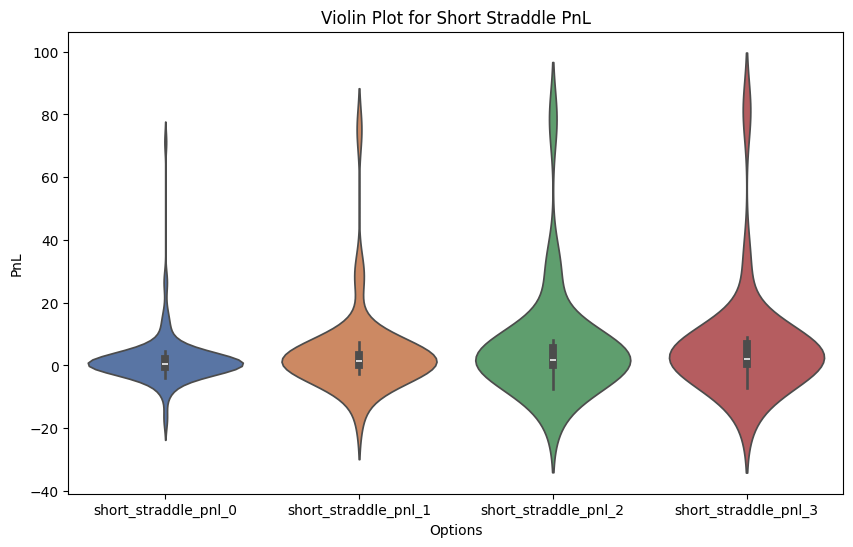

In [11]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Melt the DataFrame to have all short_straddle_pnls in one column
melted_options = options.melt(id_vars=[], value_vars=[f"short_straddle_pnl_{i}" for i in range(4)],
                              var_name='option', value_name='pnl')

# Plot the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(y='pnl', x='option', data=melted_options, palette="deep")
plt.title('Violin Plot for Short Straddle PnL')
plt.xlabel('Options')
plt.ylabel('PnL')
plt.show()


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure no NAs in the relevant columns
short_straddle = pd.DataFrame(options[["symbol", "underlying_price_0", 
                                       "short_straddle_pnl_0", "short_straddle_pnl_1", 
                                       "short_straddle_pnl_2", "short_straddle_pnl_3",
                                       "day1_underlying_price_0", "day1_underlying_price_1", 
                                       "day1_underlying_price_2", "day1_underlying_price_3",
                                       "call_price_before_earnings_0", "call_price_before_earnings_1", 
                                       "call_price_before_earnings_2", "call_price_before_earnings_3",
                                       "option_price_0", "option_price_1", "option_price_2",
                                       "option_price_3"]])

# Drop rows where any of the required columns have NaN values
short_straddle = short_straddle.dropna(subset=["symbol", "underlying_price_0", 
                                                "short_straddle_pnl_0", "short_straddle_pnl_1", 
                                                "short_straddle_pnl_2", "short_straddle_pnl_3",
                                                "day1_underlying_price_0", "day1_underlying_price_1", 
                                                "day1_underlying_price_2", "day1_underlying_price_3",
                                                "call_price_before_earnings_0", "call_price_before_earnings_1", 
                                                "call_price_before_earnings_2", "call_price_before_earnings_3",
                                                "option_price_0", "option_price_1", "option_price_2",
                                                "option_price_3"])

# Step 1: Assume each stock position is allocated equally to the portfolio
starting_capital = 10000
num_tickers = len(short_straddle)
allocation_per_ticker = starting_capital / num_tickers

# Step 2: Calculate the total premium received for the short straddle
# Short straddle premium = Call price + Put price (for each option strike)
short_straddle['premium_received_0'] = (short_straddle['call_price_before_earnings_0'] +
                                         short_straddle['option_price_0'])

short_straddle['premium_received_1'] = (short_straddle['call_price_before_earnings_1'] +
                                         short_straddle['option_price_1'])

short_straddle['premium_received_2'] = (short_straddle['call_price_before_earnings_2'] +
                                         short_straddle['option_price_2'])

short_straddle['premium_received_3'] = (short_straddle['call_price_before_earnings_3'] +
                                         short_straddle['option_price_3'])

# Step 3: Calculate position value for each ticker (using premium received)
short_straddle['position_value'] = allocation_per_ticker + short_straddle['premium_received_0']

# Step 4: Calculate the total portfolio value
short_straddle['total_portfolio_value'] = short_straddle['position_value'].sum()

# Step 5: Cumulative PnL calculation
short_straddle['cumulative_pnl'] = short_straddle['short_straddle_pnl_0'].cumsum()

# Step 6: Portfolio value calculation
short_straddle['portfolio_value'] = starting_capital + short_straddle['cumulative_pnl']

# Step 7: Calculate performance metrics
total_return = short_straddle['portfolio_value'].iloc[-1] / starting_capital - 1
annualized_return = (short_straddle['portfolio_value'].iloc[-1] / starting_capital) ** (1 / (num_tickers / 252)) - 1

# Step 8: Calculate maximum drawdown
short_straddle['rolling_max'] = short_straddle['portfolio_value'].cummax()
short_straddle['drawdown'] = short_straddle['portfolio_value'] - short_straddle['rolling_max']
max_drawdown = short_straddle['drawdown'].min()

# Step 9: Calculate percentage profit for all short straddle pnl columns
for i in range(4):
    pnl_col = f"short_straddle_pnl_{i}"
    day1_underlying_col = f"day1_underlying_price_{i}"
    short_straddle[f'percentage_profit_{i}'] = (short_straddle[pnl_col] / short_straddle['underlying_price_0']) * 100
    short_straddle[f'percentage_difference_{i}'] = (short_straddle[pnl_col] / short_straddle[day1_underlying_col]) * 100

# Print the results of the total return, annualized return, and max drawdown
print(f"Total Return: {total_return*100:.2f}%")
print(f"Annualized Return: {annualized_return*100:.2f}%")
print(f"Max Drawdown: {max_drawdown:.2f}")


Total Return: 0.81%
Annualized Return: 9.29%
Max Drawdown: -26.24


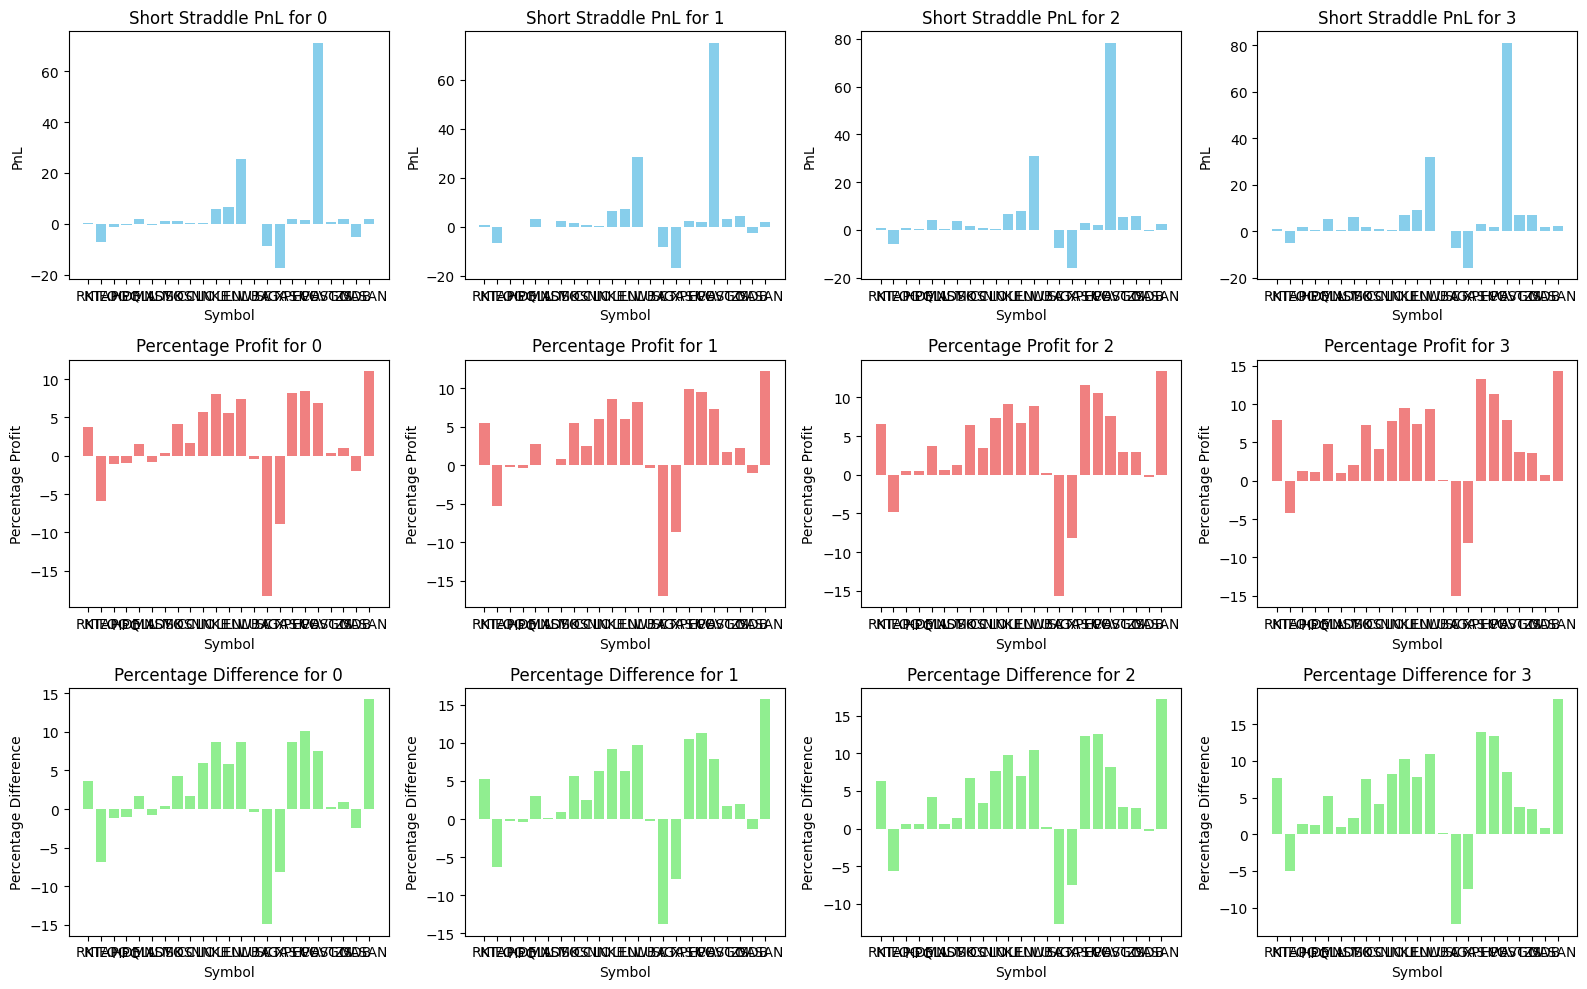

In [13]:
plt.figure(figsize=(16, 10))

# Subplots for PnL
plt.subplot(3, 4, 1)
plt.bar(short_straddle["symbol"], short_straddle["short_straddle_pnl_0"], color="skyblue")
plt.title('Short Straddle PnL for 0')
plt.xlabel('Symbol')
plt.ylabel('PnL')

plt.subplot(3, 4, 2)
plt.bar(short_straddle["symbol"], short_straddle["short_straddle_pnl_1"], color="skyblue")
plt.title('Short Straddle PnL for 1')
plt.xlabel('Symbol')
plt.ylabel('PnL')

plt.subplot(3, 4, 3)
plt.bar(short_straddle["symbol"], short_straddle["short_straddle_pnl_2"], color="skyblue")
plt.title('Short Straddle PnL for 2')
plt.xlabel('Symbol')
plt.ylabel('PnL')

plt.subplot(3, 4, 4)
plt.bar(short_straddle["symbol"], short_straddle["short_straddle_pnl_3"], color="skyblue")
plt.title('Short Straddle PnL for 3')
plt.xlabel('Symbol')
plt.ylabel('PnL')

# Subplots for Percentage Profit
plt.subplot(3, 4, 5)
plt.bar(short_straddle["symbol"], short_straddle["percentage_profit_0"], color="lightcoral")
plt.title('Percentage Profit for 0')
plt.xlabel('Symbol')
plt.ylabel('Percentage Profit')

plt.subplot(3, 4, 6)
plt.bar(short_straddle["symbol"], short_straddle["percentage_profit_1"], color="lightcoral")
plt.title('Percentage Profit for 1')
plt.xlabel('Symbol')
plt.ylabel('Percentage Profit')

plt.subplot(3, 4, 7)
plt.bar(short_straddle["symbol"], short_straddle["percentage_profit_2"], color="lightcoral")
plt.title('Percentage Profit for 2')
plt.xlabel('Symbol')
plt.ylabel('Percentage Profit')

plt.subplot(3, 4, 8)
plt.bar(short_straddle["symbol"], short_straddle["percentage_profit_3"], color="lightcoral")
plt.title('Percentage Profit for 3')
plt.xlabel('Symbol')
plt.ylabel('Percentage Profit')

# Subplots for Percentage Difference between Day1 Underlying and Short Straddle
plt.subplot(3, 4, 9)
plt.bar(short_straddle["symbol"], short_straddle["percentage_difference_0"], color="lightgreen")
plt.title('Percentage Difference for 0')
plt.xlabel('Symbol')
plt.ylabel('Percentage Difference')

plt.subplot(3, 4, 10)
plt.bar(short_straddle["symbol"], short_straddle["percentage_difference_1"], color="lightgreen")
plt.title('Percentage Difference for 1')
plt.xlabel('Symbol')
plt.ylabel('Percentage Difference')

plt.subplot(3, 4, 11)
plt.bar(short_straddle["symbol"], short_straddle["percentage_difference_2"], color="lightgreen")
plt.title('Percentage Difference for 2')
plt.xlabel('Symbol')
plt.ylabel('Percentage Difference')

plt.subplot(3, 4, 12)
plt.bar(short_straddle["symbol"], short_straddle["percentage_difference_3"], color="lightgreen")
plt.title('Percentage Difference for 3')
plt.xlabel('Symbol')
plt.ylabel('Percentage Difference')

plt.tight_layout()
plt.show()

In [14]:
# Total premium received from selling both options (assume it's stored or can be estimated)
short_straddle['initial_premium'] = short_straddle['short_straddle_pnl_0'] + short_straddle['day1_underlying_price_0'] - short_straddle['underlying_price_0']

# Or just set an approximate constant initial margin if you don’t have premium detail
short_straddle['short_straddle_return'] = (short_straddle['short_straddle_pnl_0'] / short_straddle['underlying_price_0']) * 100


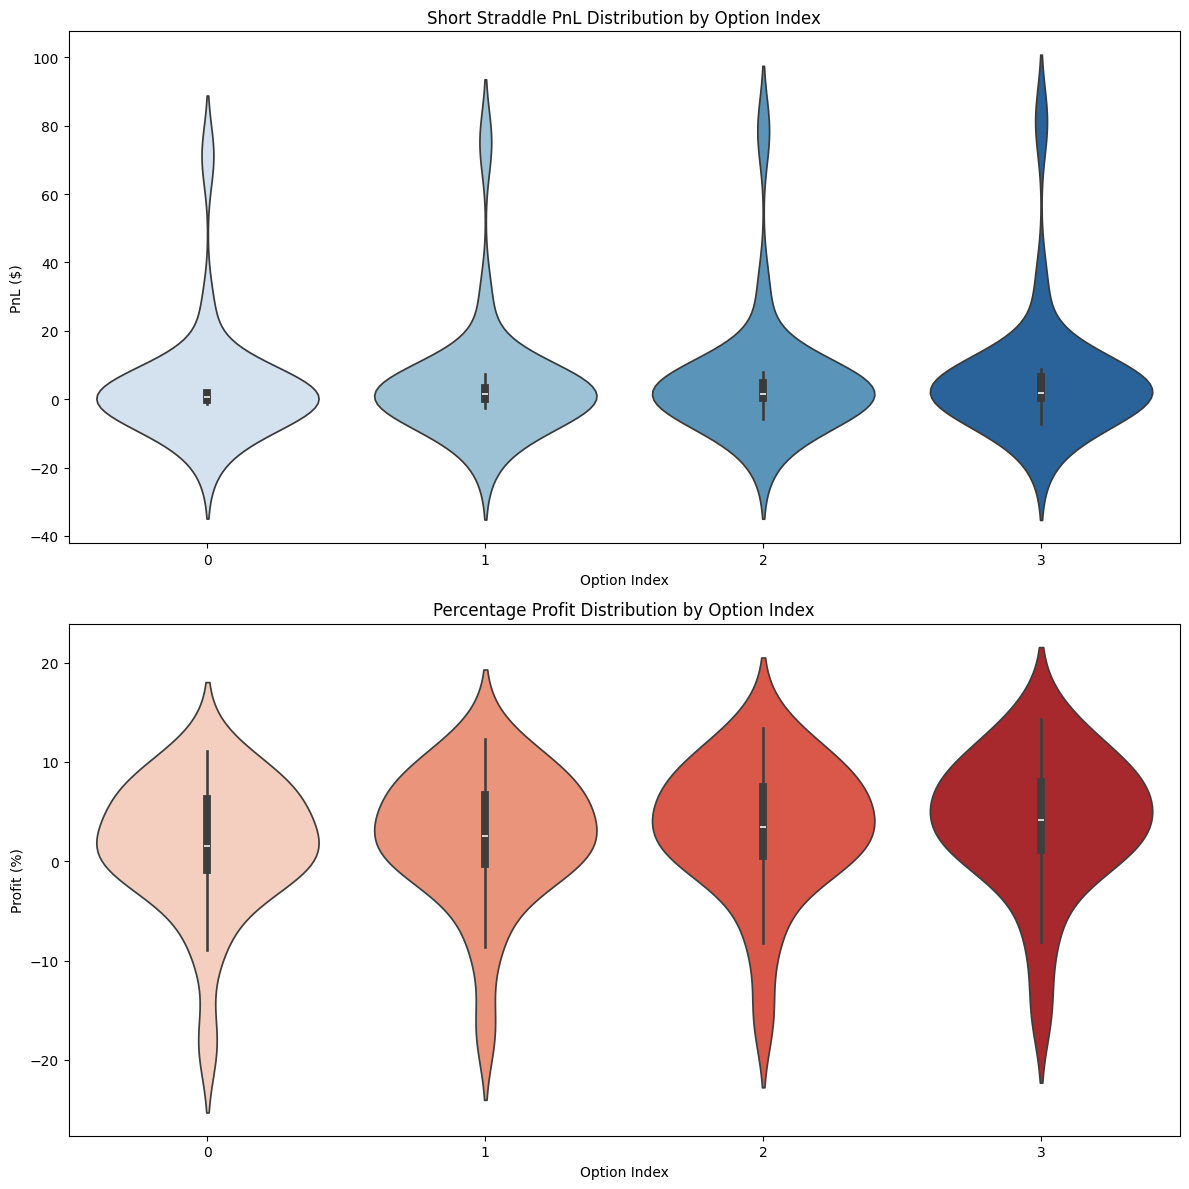

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Melt the PnL columns
pnl_data = short_straddle.melt(
    value_vars=[f'short_straddle_pnl_{i}' for i in range(4)],
    var_name='Option_Index',
    value_name='PnL'
)
pnl_data['Option_Index'] = pnl_data['Option_Index'].str.extract(r'(\d)').astype(int)

# Melt percentage profit
profit_data = short_straddle.melt(
    value_vars=[f'percentage_profit_{i}' for i in range(4)],
    var_name='Option_Index',
    value_name='Percentage_Profit'
)
profit_data['Option_Index'] = profit_data['Option_Index'].str.extract(r'(\d)').astype(int)

# Melt percentage difference
diff_data = short_straddle.melt(
    value_vars=[f'percentage_difference_{i}' for i in range(4)],
    var_name='Option_Index',
    value_name='Percentage_Diff'
)
diff_data['Option_Index'] = diff_data['Option_Index'].str.extract(r'(\d)').astype(int)

# Set up subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Violin Plot for PnL
sns.violinplot(x='Option_Index', y='PnL', data=pnl_data, ax=axes[0], palette='Blues')
axes[0].set_title('Short Straddle PnL Distribution by Option Index')
axes[0].set_xlabel('Option Index')
axes[0].set_ylabel('PnL ($)')

# Violin Plot for Percentage Profit
sns.violinplot(x='Option_Index', y='Percentage_Profit', data=profit_data, ax=axes[1], palette='Reds')
axes[1].set_title('Percentage Profit Distribution by Option Index')
axes[1].set_xlabel('Option Index')
axes[1].set_ylabel('Profit (%)')

# # Violin Plot for Percentage Difference
# sns.violinplot(x='Option_Index', y='Percentage_Diff', data=diff_data, ax=axes[2], palette='Greens')
# axes[2].set_title('Percentage Difference Distribution by Option Index')
# axes[2].set_xlabel('Option Index')
# axes[2].set_ylabel('Difference (%)')

plt.tight_layout()
plt.show()


In [16]:
short_straddle

,symbol,underlying_price_0,short_straddle_pnl_0,short_straddle_pnl_1,short_straddle_pnl_2,short_straddle_pnl_3,day1_underlying_price_0,day1_underlying_price_1,day1_underlying_price_2,day1_underlying_price_3,call_price_before_earnings_0,call_price_before_earnings_1,call_price_before_earnings_2,call_price_before_earnings_3,option_price_0,option_price_1,option_price_2,option_price_3,premium_received_0,premium_received_1,premium_received_2,premium_received_3,position_value,total_portfolio_value,cumulative_pnl,portfolio_value,rolling_max,drawdown,percentage_profit_0,percentage_difference_0,percentage_profit_1,percentage_difference_1,percentage_profit_2,percentage_difference_2,percentage_profit_3,percentage_difference_3,initial_premium,short_straddle_return
1,RKT,13.216001,0.495105,0.734036,0.872527,1.054282,13.833227,13.833227,13.833227,13.833227,0.789633,0.899731,0.973414,1.068790,0.538699,0.667531,0.732340,0.818720,1.328332,1.567263,1.705754,1.887509,436.110941,10347.227009,0.495105,10000.495105,10000.495105,0.000000,3.746252,3.579097,5.554144,5.306323,6.602051,6.307473,7.977317,7.621376,1.112331,3.746252
2,NTAP,122.101402,-7.164970,-6.499502,-5.853659,-5.157573,104.018295,104.018295,104.018295,104.018295,5.590266,5.862223,6.228377,6.620043,4.226469,4.619979,4.899668,5.204089,9.816735,10.482202,11.128045,11.824131,444.599343,10347.227009,-6.669865,9993.330135,10000.495105,-7.164970,-5.868049,-6.888182,-5.323037,-6.248422,-4.794097,-5.627529,-4.224008,-4.958333,-25.248077,-5.868049
6,EOG,131.654861,-1.455348,-0.319955,0.708272,1.700363,124.801041,124.801041,124.801041,124.801041,2.767194,3.335797,3.899755,4.445294,1.976416,2.543208,3.007476,3.454028,4.743611,5.879004,6.907231,7.899322,439.526220,10347.227009,-8.125214,9991.874786,10000.495105,-8.620318,-1.105427,-1.166135,-0.243026,-0.256372,0.537976,0.567521,1.291531,1.362459,-8.309169,-1.105427
9,HPQ,33.776001,-0.304982,-0.120032,0.179752,0.391068,30.874001,30.874001,30.874001,30.874001,1.331288,1.409949,1.517832,1.635518,0.989729,1.096019,1.287919,1.381549,2.321017,2.505968,2.805751,3.017067,437.103626,10347.227009,-8.430196,9991.569804,10000.495105,-8.925301,-0.902955,-0.987829,-0.355376,-0.388779,0.532187,0.582210,1.157828,1.266658,-3.206983,-0.902955
10,DELL,112.197655,1.752403,3.123779,4.240613,5.360010,102.429604,102.429604,102.429604,102.429604,5.896895,6.513311,7.111000,7.710138,4.425905,5.180864,5.700010,6.220268,10.322800,11.694175,12.811010,13.930406,445.105408,10347.227009,-6.677793,9993.322207,10000.495105,-7.172897,1.561889,1.710837,2.784175,3.049683,3.779592,4.140027,4.777292,5.232872,-8.015648,1.561889
11,MNST,52.025997,-0.408178,0.048921,0.299768,0.543235,55.057072,54.880684,54.880684,54.880684,2.386697,2.510280,2.655623,2.795246,1.262197,1.419325,1.524829,1.628673,3.648894,3.929605,4.180452,4.423919,438.431502,10347.227009,-7.085971,9992.914029,10000.495105,-7.581075,-0.784565,-0.741372,0.094031,0.089140,0.576189,0.546218,1.044161,0.989848,2.622897,-0.784565
12,ADSK,291.688354,0.928166,2.454070,3.842377,6.078258,271.830719,271.830719,271.830719,271.830719,10.644285,11.310820,12.098153,13.323464,8.453163,9.312531,9.913504,10.924075,19.097447,20.623351,22.011658,24.247539,453.880056,10347.227009,-6.157804,9993.842196,10000.495105,-6.652909,0.318205,0.341450,0.841333,0.902793,1.317288,1.413518,2.083819,2.236045,-18.929469,0.318205
18,MOS,25.315998,1.038465,1.399890,1.643268,1.850627,24.568375,24.568375,24.568375,24.568375,0.913881,1.042340,1.173258,1.286326,0.556209,0.789175,0.901635,0.995927,1.470091,1.831516,2.074893,2.282253,436.252699,10347.227009,-5.119339,9994.880661,10000.495105,-5.614444,4.102011,4.226837,5.529666,5.697936,6.491025,6.688549,7.310110,7.532559,0.290842,4.102011
20,CCL,21.254002,0.358384,0.540654,0.728637,0.876035,21.164000,21.164000,21.164000,21.164000,2.404717,2.491541,2.592792,2.673586,0.117666,0.213113,0.299844,0.366449,2.522384,2.704654,2.892636,3.040035,437.304992,10347.227009,-4.760955,9995.239045,10000.495105,-5.256060,1.686196,1.6933

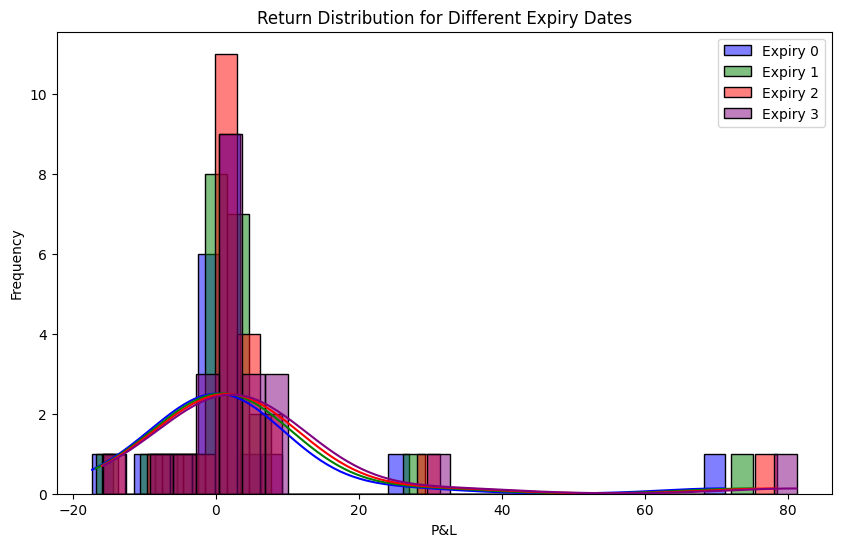

Win Rate for Expiry 0: 65.22%
Win Rate for Expiry 1: 69.57%
Win Rate for Expiry 2: 82.61%
Win Rate for Expiry 3: 86.96%
Risk/Reward Ratio for Expiry 0: 0.47
Risk/Reward Ratio for Expiry 1: 0.52
Risk/Reward Ratio for Expiry 2: 0.51
Risk/Reward Ratio for Expiry 3: 0.54
Maximum Drawdown for Expiry 0: -18.03
Maximum Drawdown for Expiry 1: -9.45
Maximum Drawdown for Expiry 2: -6.71
Maximum Drawdown for Expiry 3: -4.89


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# 1. Return Distribution: P&L for each expiry
plt.figure(figsize=(10, 6))
sns.histplot(short_straddle['short_straddle_pnl_0'], kde=True, label='Expiry 0', color='blue', bins=30)
sns.histplot(short_straddle['short_straddle_pnl_1'], kde=True, label='Expiry 1', color='green', bins=30)
sns.histplot(short_straddle['short_straddle_pnl_2'], kde=True, label='Expiry 2', color='red', bins=30)
sns.histplot(short_straddle['short_straddle_pnl_3'], kde=True, label='Expiry 3', color='purple', bins=30)
plt.title('Return Distribution for Different Expiry Dates')
plt.xlabel('P&L')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 2. Win Rate: Calculate win rate for each expiry date (each P&L column)
win_rate_0 = (short_straddle['short_straddle_pnl_0'] > 0).mean() * 100
win_rate_1 = (short_straddle['short_straddle_pnl_1'] > 0).mean() * 100
win_rate_2 = (short_straddle['short_straddle_pnl_2'] > 0).mean() * 100
win_rate_3 = (short_straddle['short_straddle_pnl_3'] > 0).mean() * 100

print(f'Win Rate for Expiry 0: {win_rate_0:.2f}%')
print(f'Win Rate for Expiry 1: {win_rate_1:.2f}%')
print(f'Win Rate for Expiry 2: {win_rate_2:.2f}%')
print(f'Win Rate for Expiry 3: {win_rate_3:.2f}%')

# 3. Risk/Reward Ratios: Calculate for each expiry date (each P&L column)
def calculate_risk_reward_ratio(pnl):
    positive_pnl = pnl[pnl > 0]
    negative_pnl = pnl[pnl < 0]
    reward = positive_pnl.mean() if len(positive_pnl) > 0 else 0
    risk = abs(negative_pnl.min())  # Maximum drawdown (worst loss)
    return reward / risk if risk > 0 else np.nan

risk_reward_0 = calculate_risk_reward_ratio(short_straddle['short_straddle_pnl_0'])
risk_reward_1 = calculate_risk_reward_ratio(short_straddle['short_straddle_pnl_1'])
risk_reward_2 = calculate_risk_reward_ratio(short_straddle['short_straddle_pnl_2'])
risk_reward_3 = calculate_risk_reward_ratio(short_straddle['short_straddle_pnl_3'])

print(f'Risk/Reward Ratio for Expiry 0: {risk_reward_0:.2f}')
print(f'Risk/Reward Ratio for Expiry 1: {risk_reward_1:.2f}')
print(f'Risk/Reward Ratio for Expiry 2: {risk_reward_2:.2f}')
print(f'Risk/Reward Ratio for Expiry 3: {risk_reward_3:.2f}')

# 4. Maximum Drawdown: Calculate for each expiry date (each P&L column)
def calculate_max_drawdown(pnl):
    cumulative_pnl = pnl.cumsum()
    peak = cumulative_pnl.cummax()
    drawdown = (cumulative_pnl - peak) / peak
    return drawdown.min()

max_drawdown_0 = calculate_max_drawdown(short_straddle['short_straddle_pnl_0'])
max_drawdown_1 = calculate_max_drawdown(short_straddle['short_straddle_pnl_1'])
max_drawdown_2 = calculate_max_drawdown(short_straddle['short_straddle_pnl_2'])
max_drawdown_3 = calculate_max_drawdown(short_straddle['short_straddle_pnl_3'])

print(f'Maximum Drawdown for Expiry 0: {max_drawdown_0:.2f}')
print(f'Maximum Drawdown for Expiry 1: {max_drawdown_1:.2f}')
print(f'Maximum Drawdown for Expiry 2: {max_drawdown_2:.2f}')
print(f'Maximum Drawdown for Expiry 3: {max_drawdown_3:.2f}')


# Calendar Spread

In [18]:
df[["underlying_price_2", "day1_underlying_price_2"]]

,underlying_price_2,day1_underlying_price_2
0,NaN,NaN
1,13.216001,13.833227
2,122.101402,104.018295
3,NaN,NaN
4,NaN,NaN
...,...,...
156,NaN,NaN
157,NaN,NaN
158,16.992445,13.253358
159,NaN,NaN


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

# Black-Scholes formula for American put option with early exercise consideration
def american_put_price(S, K, T, r, sigma):
    if T <= 0:
        return max(K - S, 0)  # Immediate exercise if expiration time is zero
    
    # Black-Scholes formula (European option price)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    european_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    # Intrinsic value (early exercise value)
    intrinsic_value = max(K - S, 0)
    
    # American put value is the maximum of European price and intrinsic value (early exercise check)
    return max(european_price, intrinsic_value)

# Risk-free rate
r = 0.01

# Copy DataFrame
calendar_spread = df.copy()

# Calendar spread P&L calculator (short leg = 0, long leg = 1, 2, or 3)
def calculate_calendar_pnl(row, long_leg_index):
    try:
        S_0 = row['underlying_price_0']
        K = row['strike_0']
        short_option_price = row['option_price_0']
        long_option_price = row[f'option_price_{long_leg_index}']
        
        time_to_expiry_short = (row['expiry_0'] - row['timestamp']).total_seconds() / (365 * 24 * 60 * 60)
        time_to_expiry_long = (row[f'expiry_{long_leg_index}'] - row['timestamp']).total_seconds() / (365 * 24 * 60 * 60)
        
        days_passed = 1 / 252
        time_to_expiry_short_after = max(0.0001, time_to_expiry_short - days_passed)
        time_to_expiry_long_after = max(0.0001, time_to_expiry_long - days_passed)
        
        S_after_short = row['day1_underlying_price_0']
        S_after_long = row[f'day1_underlying_price_{long_leg_index}']
        
        IV_after_short = row['day1_implied_vol_0']
        IV_after_long = row[f'day1_implied_vol_{long_leg_index}']
        
        net_debit = long_option_price - short_option_price

        short_option_price_after = american_put_price(S_after_short, K, time_to_expiry_short_after, r, IV_after_short)
        long_option_price_after = american_put_price(S_after_long, K, time_to_expiry_long_after, r, IV_after_long)

        pnl = (long_option_price_after - long_option_price) + (short_option_price - short_option_price_after)
        return pnl

    except Exception as e:
        print(f"Error at index {row.name} for leg {long_leg_index}: {e}")
        return np.nan

# Compute P&L for long legs 1, 2, 3
for leg_index in [1, 2, 3]:
    col_name = f'P&L_{leg_index}'
    calendar_spread[col_name] = calendar_spread.apply(lambda row: calculate_calendar_pnl(row, leg_index), axis=1)

# Drop rows with all P&Ls missing
calendar_spread.dropna(subset=['P&L_1', 'P&L_2', 'P&L_3'], how='all', inplace=True)

# Calculate total P&L for the strategy
calendar_spread['total_pnl'] = calendar_spread[['P&L_1', 'P&L_2', 'P&L_3']].sum(axis=1)


In [20]:
calendar_spread['total_pnl'].head()

1     0.417643
2    -1.477623
6    -0.865490
9    -0.495706
10   -0.656777
Name: total_pnl, dtype: float64

In [21]:
# 1. Total Return
total_pnl_sum = calendar_spread['total_pnl'].sum()
initial_capital = len(calendar_spread)  # assuming 1 unit capital per trade
total_return = (total_pnl_sum / initial_capital) * 100

# 2. Annualized Return
annualized_return = ((1 + total_pnl_sum / initial_capital) ** (252 / initial_capital)) - 1

# 3. Max Drawdown
cumulative_returns = calendar_spread['total_pnl'].cumsum()
peak = cumulative_returns.cummax()
drawdown = (cumulative_returns - peak) / peak.replace(0, np.nan)
max_drawdown = drawdown.min() * 100

# Print
print(f"Calendar Spread - Total Return: {total_return:.2f}%")
print(f"Calendar Spread - Annualized Return: {annualized_return * 100:.2f}%")
print(f"Calendar Spread - Max Drawdown: {max_drawdown:.2f}%")


Calendar Spread - Total Return: 33.84%
Calendar Spread - Annualized Return: 557.55%
Calendar Spread - Max Drawdown: -1182.97%


In [22]:
option2 = short_straddle[~short_straddle["short_straddle_pnl_2"].isna()][["short_straddle_pnl_0", "short_straddle_pnl_2"]]
# Calculate the average P&L for the short straddle across both columns
calendar_spread['Average Short Straddle P&L'] = option2[['short_straddle_pnl_0', 'short_straddle_pnl_2']].mean(axis=1)

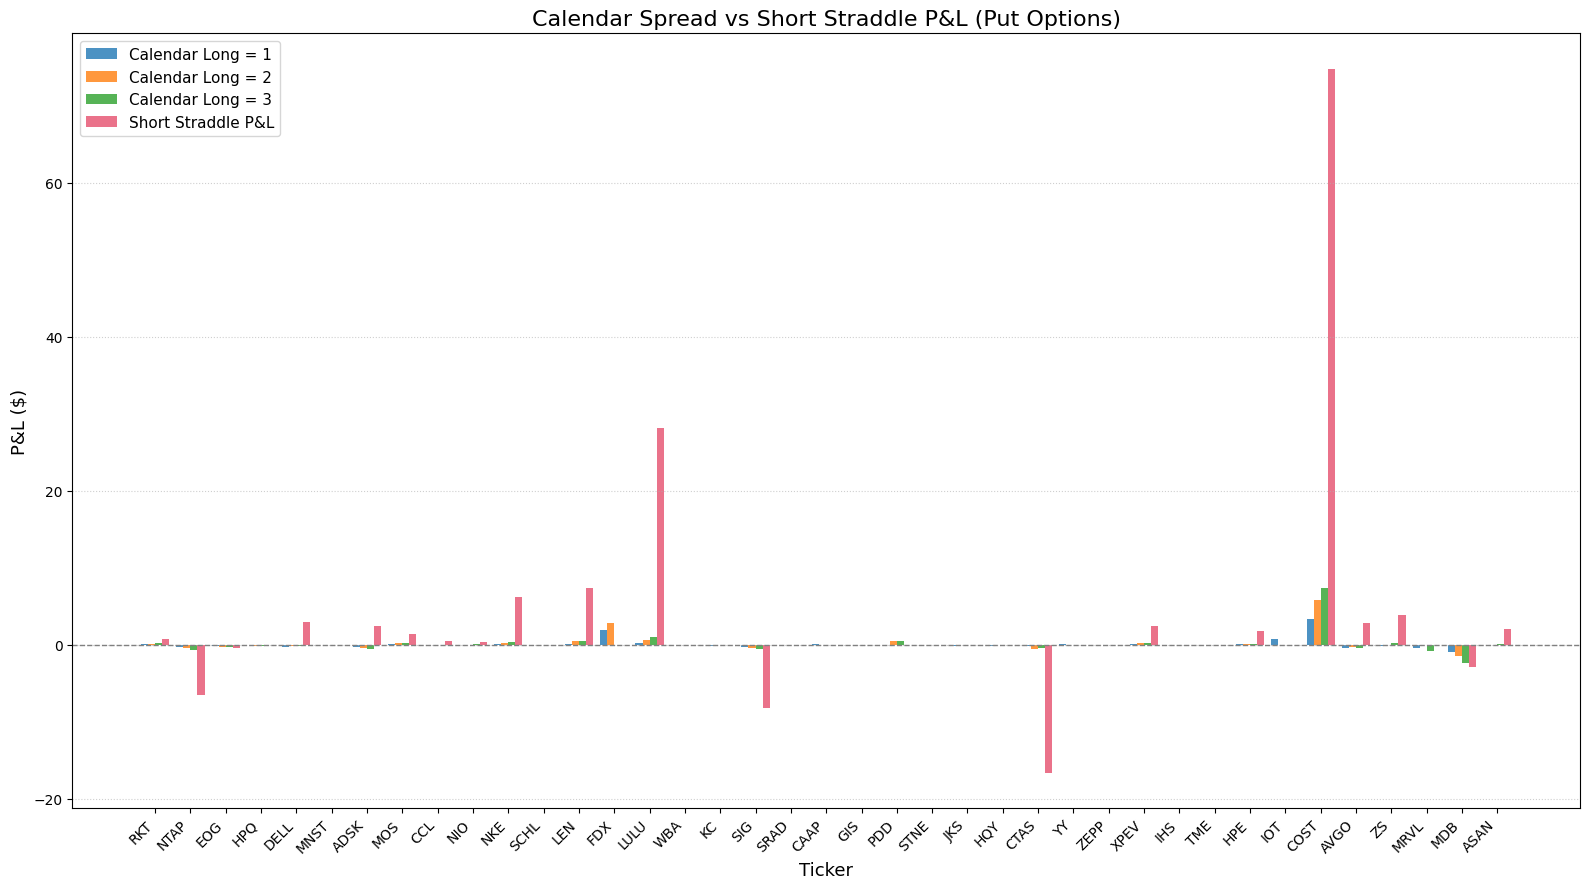

In [23]:
# Plotting
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 9))
bar_width = 0.2
x = np.arange(len(calendar_spread))  # numeric positions for each symbol

# Plot each bar group, offset from center
plt.bar(x - 1.5 * bar_width, calendar_spread['P&L_1'], width=bar_width, label='Calendar Long = 1', alpha=0.8)
plt.bar(x - 0.5 * bar_width, calendar_spread['P&L_2'], width=bar_width, label='Calendar Long = 2', alpha=0.8)
plt.bar(x + 0.5 * bar_width, calendar_spread['P&L_3'], width=bar_width, label='Calendar Long = 3', alpha=0.8)
plt.bar(x + 1.5 * bar_width, calendar_spread['Average Short Straddle P&L'], width=bar_width,
        color='crimson', alpha=0.6, label='Short Straddle P&L')

# Visual polish
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Calendar Spread vs Short Straddle P&L (Put Options)', fontsize=16)
plt.xlabel('Ticker', fontsize=13)
plt.ylabel('P&L ($)', fontsize=13)
plt.xticks(x, calendar_spread['symbol'], rotation=45, ha='right')
plt.legend(frameon=True, fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


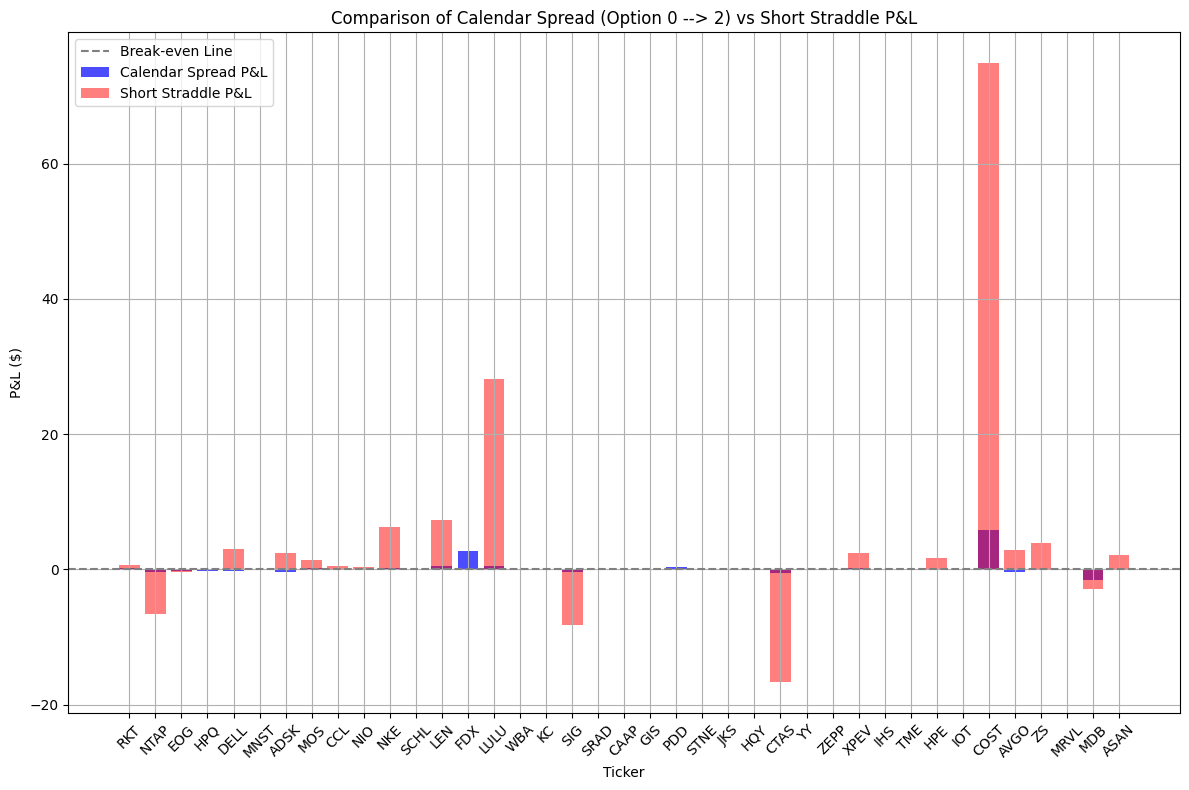

In [24]:
# Plotting the comparison between calendar spread P&L and short straddle P&L
plt.figure(figsize=(12, 8))

# Plot Calendar Spread P&L
plt.bar(calendar_spread['symbol'], calendar_spread['P&L_2'], color='blue', alpha=0.7, label='Calendar Spread P&L')

# Plot Total Short Straddle P&L
plt.bar(calendar_spread['symbol'], calendar_spread['Average Short Straddle P&L'], color='red', alpha=0.5, label='Short Straddle P&L')

# Add a horizontal line for break-even
plt.axhline(0, color='gray', linestyle='--', label='Break-even Line')

# Labels and Title
plt.title('Comparison of Calendar Spread (Option 0 --> 2) vs Short Straddle P&L')
plt.xlabel('Ticker')
plt.ylabel('P&L ($)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [25]:

# Portfolio value for calendar spread strategy
calendar_spread['position_value'] = allocation_per_ticker + calendar_spread['P&L_2']
calendar_spread['portfolio_value'] = starting_capital + calendar_spread['P&L_2'].cumsum()

# Calculate performance metrics for calendar spread
total_return_calendar = calendar_spread['portfolio_value'].iloc[-1] / starting_capital - 1
annualized_return_calendar = (calendar_spread['portfolio_value'].iloc[-1] / starting_capital) ** (1 / (num_tickers / 252)) - 1

# Max Drawdown for calendar spread
calendar_spread['rolling_max'] = calendar_spread['portfolio_value'].cummax()
calendar_spread['drawdown'] = calendar_spread['portfolio_value'] - calendar_spread['rolling_max']
max_drawdown_calendar = calendar_spread['drawdown'].min()

print(f"Calendar Spread - Total Return: {total_return_calendar*100:.2f}%")
print(f"Calendar Spread - Annualized Return: {annualized_return_calendar*100:.2f}%")
print(f"Calendar Spread - Max Drawdown: {max_drawdown_calendar*100:.2f}%")


Calendar Spread - Total Return: 0.06%
Calendar Spread - Annualized Return: 0.71%
Calendar Spread - Max Drawdown: -193.57%


In [26]:
df = df.assign(**{
    col: pd.to_datetime(df[col]).dt.tz_localize(None).dt.normalize() + pd.Timedelta(hours=23, minutes=59, seconds=59)
    for col in df.filter(regex='expiry', axis=1)
})

df = df.assign(**{
    col: pd.to_datetime(df[col]).dt.tz_localize(None)
    for col in df.filter(regex='timestamp', axis=1)
})


In [27]:
df['days_diff'] = ((df['day1_timestamp'] - df['timestamp']).dt.days).clip(lower=1)
df = df.dropna(subset="days_diff")

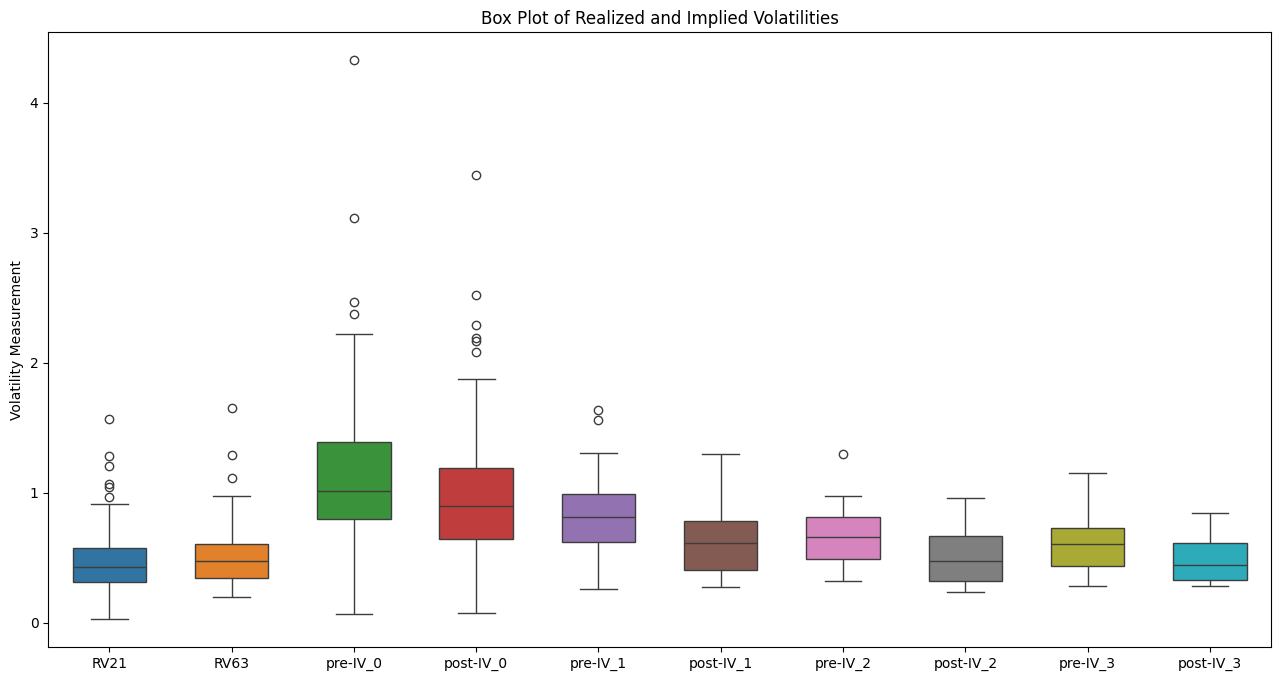

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plots = df[["RV21", "RV63", "implied_vol_0", "day1_implied_vol_0", "implied_vol_1", "day1_implied_vol_1", 
            "implied_vol_2", "day1_implied_vol_2", "implied_vol_3", "day1_implied_vol_3"]]

# Rename the columns for clarity
plots.columns = ["RV21", "RV63", "pre-IV_0", "post-IV_0", "pre-IV_1", "post-IV_1", "pre-IV_2", 
                 "post-IV_2", "pre-IV_3", "post-IV_3"]

plt.figure(figsize=(14, 8))

# Boxplot with adjusted width and more space
sns.boxplot(data=plots[["RV21", "RV63", "pre-IV_0", "post-IV_0", "pre-IV_1", "post-IV_1", "pre-IV_2", 
                       "post-IV_2", "pre-IV_3", "post-IV_3"]], width=0.6)

# Title of the plot
plt.title("Box Plot of Realized and Implied Volatilities")

plt.ylabel("Volatility Measurement")

# Show the plot with more spacing around it
plt.tight_layout(pad=5.0)  # Adjust the padding for better spacing
plt.show()



In [29]:
# Calendar Spread P&L Example — Only if long option (option 2) is present

def calendar_spread_example(row):
    if pd.notnull(row.get("day1_option_price_2")):
        long_price = row["option_price_2"]
        short_price = row["option_price_0"]
        net_cost = long_price - short_price

        long_price_day1 = row["day1_option_price_2"]
        short_price_day1 = row["day1_option_price_0"]
        exit_value = long_price_day1 - short_price_day1

        pnl = exit_value - net_cost
        row["pnl"] = pnl
        row["net_cost"] = net_cost
        row["exit_value"] = exit_value
    else:
        row["pnl"] = None  # Or 0, depending on how you want to treat missing
        row["net_cost"] = None
        row["exit_value"] = None
    return row

calendar_candidates = df.apply(calendar_spread_example, axis=1).dropna(subset="pnl")
print(f"Net Option Cost: ${calendar_candidates["net_cost"].sum()}")
print(f"Option Exit Value: ${calendar_candidates["exit_value"].sum()}")
print(f"Profit: ${calendar_candidates["pnl"].sum()}")

Net Option Cost: $22.65768288629505
Option Exit Value: $27.464791550433304
Profit: $4.807108664138254


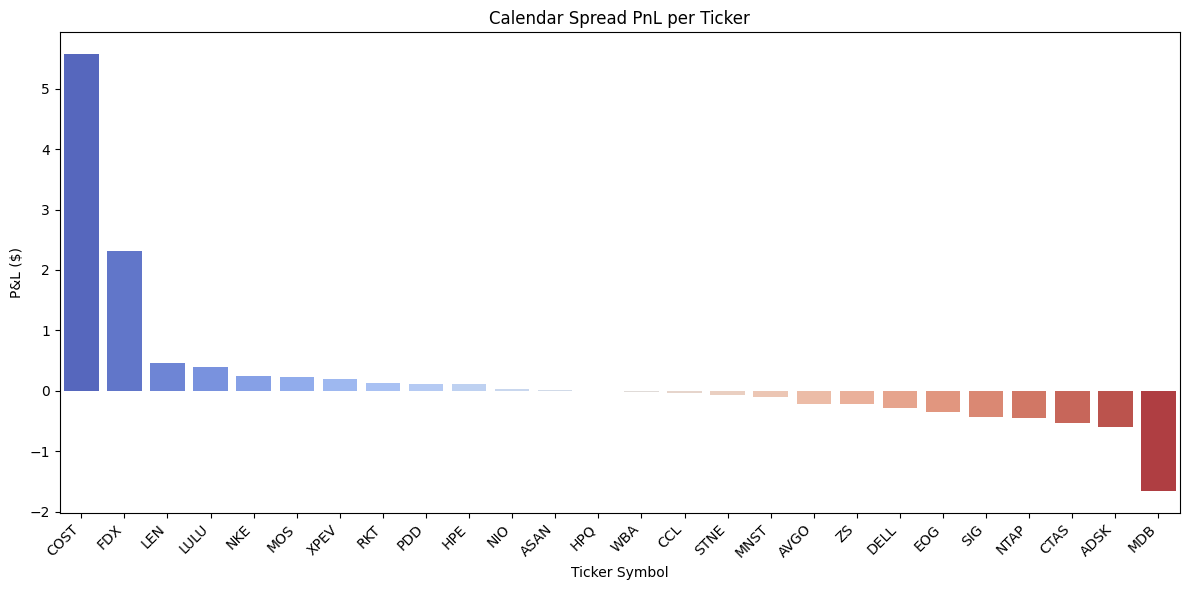

In [30]:

plot_data = calendar_candidates[["symbol", "pnl"]].sort_values(by="pnl", ascending=False)

# Set plot style
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="symbol", y="pnl", palette="coolwarm")

plt.title("Calendar Spread PnL per Ticker")
plt.xlabel("Ticker Symbol")
plt.ylabel("P&L ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [31]:
df['vol_crush_0'] = ((df['implied_vol_0'] - df['day1_implied_vol_0']) / df['implied_vol_0']) * 100
df['vol_crush_1'] = ((df['implied_vol_1'] - df['day1_implied_vol_1']) / df['implied_vol_1']) * 100
df['vol_crush_2'] = ((df['implied_vol_2'] - df['day1_implied_vol_2']) / df['implied_vol_2']) * 100
df['vol_crush_3'] = ((df['implied_vol_3'] - df['day1_implied_vol_3']) / df['implied_vol_3']) * 100


In [32]:
df['actual_move_pct_0'] = (abs(df['day1_underlying_price_0'] - df['underlying_price_0']) / df['underlying_price_0']) * 100
df['actual_move_pct_1'] = (abs(df['day1_underlying_price_1'] - df['underlying_price_1']) / df['underlying_price_1']) * 100
df['actual_move_pct_2'] = (abs(df['day1_underlying_price_2'] - df['underlying_price_2']) / df['underlying_price_2']) * 100
df['actual_move_pct_3'] = (abs(df['day1_underlying_price_3'] - df['underlying_price_3']) / df['underlying_price_3']) * 100


In [33]:
df[["actual_move_pct_0", "actual_move_pct_1", "actual_move_pct_2", "actual_move_pct_3"]].describe()

,actual_move_pct_0,actual_move_pct_1,actual_move_pct_2,actual_move_pct_3
count,122.000000,40.000000,26.000000,25.000000
mean,8.699565,8.915870,8.599930,8.544466
std,6.887661,5.844714,6.266978,6.374120
min,0.000000,0.377230,0.377230,0.377230
25%,3.616344,4.644896,4.690218,4.670298
50%,6.635181,7.122821,6.776264,6.759583
75%,12.585771,14.006706,13.497954,14.465677
max,27.944983,22.674491,22.720859,22.720859


In [34]:
df['vol_crush_0'].max()

np.float64(66.77642818285769)

In [35]:
df["iv_diff"] = df["implied_vol_0"] - df["implied_vol_2"]
iv_filtered = df[df["iv_diff"] > 0.10]  # Tune threshold as needed


In [36]:
def calendar_spread_example(row, iv_diff_threshold=0.10, max_dd_threshold=0, min_pnl_threshold=0):
    if pd.notnull(row.get("day1_option_price_2")):
        long_price = row["option_price_2"]
        short_price = row["option_price_0"]
        net_cost = long_price - short_price

        long_price_day1 = row["day1_option_price_2"]
        short_price_day1 = row["day1_option_price_0"]
        exit_value = long_price_day1 - short_price_day1

        pnl = exit_value - net_cost
        
        # Filtering based on IV differential
        iv_diff = row["implied_vol_0"] - row["day1_implied_vol_0"]
        if iv_diff < iv_diff_threshold:
            return None  # Skip trades with insufficient IV differential

        # Calculating max drawdown
        max_drawdown = net_cost - exit_value
        if max_drawdown > max_dd_threshold * pnl:  # Skip if drawdown is too large relative to P&L
            return None

        # Only include trades with a reasonable PnL
        if pnl < min_pnl_threshold:
            return None

        row["pnl"] = pnl
        row["net_cost"] = net_cost
        row["exit_value"] = exit_value
    else:
        row["pnl"] = None  # Or 0, depending on how you want to treat missing
        row["net_cost"] = None
        row["exit_value"] = None
    return row

calendar_candidates_select = df.apply(lambda row: calendar_spread_example(row), axis=1).dropna(subset="pnl")

# Analyze PnL and performance
calendar_candidates_select[["pnl", "net_cost", "exit_value"]].sum()

pnl            9.296390
net_cost       8.303187
exit_value    17.599576
dtype: float64

In [37]:
calendar_candidates_select

,symbol,RV21,RV63,VolRatio3_21,VolRatio5_63,DolVol_21,timestamp,expiry_0,strike_0,type_0,implied_vol_0,delta_0,option_price_0,pv_dividend_0,gamma_0,vega_0,theta_0,underlying_price_0,expiry_1,strike_1,type_1,implied_vol_1,delta_1,option_price_1,pv_dividend_1,gamma_1,vega_1,theta_1,underlying_price_1,expiry_2,strike_2,type_2,implied_vol_2,delta_2,option_price_2,pv_dividend_2,gamma_2,vega_2,theta_2,underlying_price_2,expiry_3,strike_3,type_3,implied_vol_3,delta_3,option_price_3,pv_dividend_3,gamma_3,vega_3,theta_3,underlying_price_3,day1_timestamp,day1_expiry_0,day1_strike_0,day1_type_0,day1_implied_vol_0,day1_delta_0,day1_option_price_0,day1_pv_dividend_0,day1_gamma_0,day1_vega_0,day1_theta_0,day1_underlying_price_0,day1_expiry_1,day1_strike_1,day1_type_1,day1_implied_vol_1,day1_delta_1,day1_option_price_1,day1_pv_dividend_1,day1_gamma_1,day1_vega_1,day1_theta_1,day1_underlying_price_1,day1_expiry_2,day1_strike_2,day1_type_2,day1_implied_vol_2,day1_delta_2,day1_option_price_2,day1_pv_dividend_2,day1_gamma_2,day1_vega_2,day1_theta_2,day1_underlying_price_2,day1_expiry_3,day1_strike_3,day1_type_3,day1_implied_vol_3,day1_delta_3,day1_option_price_3,day1_pv_dividend_3,day1_gamma_3,day1_vega_3,day1_theta_3,day1_underlying_price_3,T_before_0,T_after_0,call_price_before_earnings_0,call_price_after_earnings_0,T_before_1,T_after_1,call_price_before_earnings_1,call_price_after_earnings_1,T_before_2,T_after_2,call_price_before_earnings_2,call_price_after_earnings_2,T_before_3,T_after_3,call_price_before_earnings_3,call_price_after_earnings_3,short_straddle_pnl_0,short_straddle_pnl_1,short_straddle_pnl_2,short_straddle_pnl_3,days_diff,vol_crush_0,vol_crush_1,vol_crush_2,vol_crush_3,actual_move_pct_0,actual_move_pct_1,actual_move_pct_2,actual_move_pct_3,iv_diff,pnl,net_cost,exit_value
1,RKT,0.553043,0.515409,1.320358,1.357837,3.508951e+05,2025-02-27 18:22:48.113577,2025-02-28 23:59:59,13.0,P,2.221832,-0.421969,0.538699,0.0,0.242353,0.002871,-0.426589,13.216001,2025-03-07 23:59:59,13.0,P,0.994446,-0.424341,0.667531,0.0,0.200739,0.007745,-0.048376,13.216001,2025-03-14 23:59:59,13.0,P,0.795464,-0.423928,0.732340,0.0,0.184308,0.010542,-0.027633,13.216001,2025-03-21 23:59:59,13.0,P,0.728779,-0.423362,0.818720,0.0,0.166396,0.012740,-0.020605,13.216001,2025-02-28 14:55:50.174505,2025-02-28 23:59:59,13.0,P,1.871096,-0.099013,0.032710,0.0,0.256099,0.000605,-0.032710,13.833227,2025-03-07 23:59:59,13.0,P,0.755266,-0.259582,0.243931,0.0,0.221447,0.006633,-0.033007,13.833227,2025-03-14 23:59:59,13.0,P,0.657966,-0.289537,0.350000,0.0,0.191296,0.009257,-0.021344,13.833227,2025-03-21 23:59:59,13.0,P,0.623604,-0.307134,0.442644,0.0,0.170492,0.011312,-0.016308,13.833227,0.003381,0.003381,0.789633,1.092290,0.022559,0.022559,0.899731,1.121026,0.041737,0.041737,0.973414,1.226501,0.060915,0.060915,1.068790,1.327566,0.495105,0.734036,0.872527,1.054282,1.0,15.785908,24.051596,17.285256,14.431566,4.670298,4.670298,4.670298,4.670298,1.426368,0.123649,0.193642,0.317290
22,NKE,0.297330,0.302436,0.726250,0.800938,6.876967e+06,2025-03-20 17:39:14.003404,2025-03-21 23:59:59,65.0,P,1.772450,-0.119309,0.433618,0.0,0.028297,0.008194,-0.433586,72.533836,2025-03-28 23:59:59,65.0,P,0.743288,-0.145053,0.629582,0.0,0.028568,0.026981,-0.107062,72.533836,2025-04-04 23:59:59,65.0,P,0.590685,-0.161886,0.790319,0.0,0.028222,0.036641,-0.071508,72.533836,2025-04-11 23:59:59,65.0,P,0.518952,-0.173071,0.915838,0.0,0.027771,0.044159,-0.050932,72.533836,2025-03-21 15:51:15.345257,2025-03-21 23:59:59,65.0,P,1.084065,-0.045002,0.030000,0.0,0.059370,0.001350,-0.030000,67.630852,2025-03-28 23:59:59,65.0,P,0.327171,-0.182609,0.315932,0.0,0.085725,0.024396,-0.056307,67.630852,2025-04-04 23:59:59,65.0,P,0.315069,-0.243500,0.623858,0.0,0.075198,0.040234,-0.043623,67.630852,2025-04-11 23:59:59,65.0,P,0.302274,-0.270370,0.845872,0.0,0.067770,0.055247,-0.037837,67.630852,0.003464,0.003464,8.082499,3.326359,0.022642,0.022642,8.250418,3.069909,0.041820,0.041820,8.450018,3.419525,0.060998,0.060998,8.6281

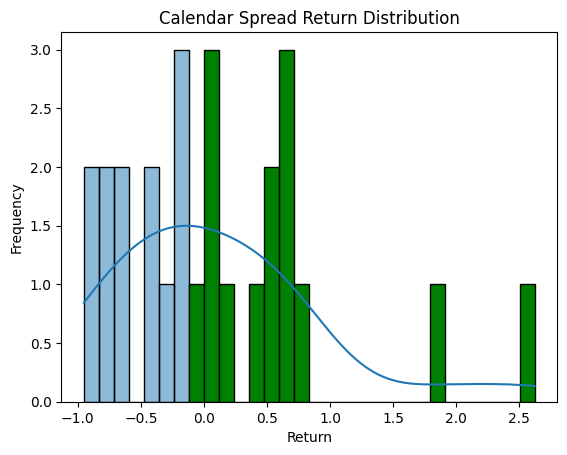

In [38]:
calendar_candidates["return"] = calendar_candidates["pnl"] / calendar_candidates["net_cost"]
calendar_candidates_select["return"] = calendar_candidates_select["pnl"] / calendar_candidates_select["net_cost"]

import seaborn as sns
import matplotlib.pyplot as plt

# Create the plot
ax = sns.histplot(calendar_candidates["return"].dropna(), bins=30, kde=True)
plt.title("Calendar Spread Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")

# Color bars with x > 1 as green
for patch in ax.patches:
    if patch.get_x() + patch.get_width() > 0:
        patch.set_facecolor("green")

plt.show()



In [39]:
win_rate = (calendar_candidates["pnl"] > 0).mean()
print(f"Win Rate: {win_rate:.2%}")

Win Rate: 50.00%


In [40]:
wins = calendar_candidates[calendar_candidates["pnl"] > 0]
losses = calendar_candidates[calendar_candidates["pnl"] < 0]

avg_gain = wins["pnl"].mean()
avg_loss = abs(losses["pnl"].mean())

risk_reward_ratio = avg_gain / avg_loss if avg_loss > 0 else float('inf')
print(f"Risk/Reward Ratio: {risk_reward_ratio:.2f}")


Risk/Reward Ratio: 1.97


In [41]:
calendar_candidates = calendar_candidates.sort_values("day1_timestamp")  # or "entry_date"
calendar_candidates["cumulative_pnl"] = calendar_candidates["pnl"].cumsum()

# Calculate running max
calendar_candidates["running_max"] = calendar_candidates["cumulative_pnl"].cummax()

# Drawdown = peak - current
calendar_candidates["drawdown"] = calendar_candidates["running_max"] - calendar_candidates["cumulative_pnl"]

max_drawdown = calendar_candidates["drawdown"].max()
print(f"Max Drawdown: ${max_drawdown:.2f}")


Max Drawdown: $3.43


In [42]:
calendar_candidates_select = calendar_candidates_select.sort_values("day1_timestamp")  # or "entry_date"
calendar_candidates_select["cumulative_pnl"] = calendar_candidates_select["pnl"].cumsum()

# Calculate running max
calendar_candidates_select["running_max"] = calendar_candidates_select["cumulative_pnl"].cummax()

# Drawdown = peak - current
calendar_candidates_select["drawdown"] = calendar_candidates_select["running_max"] - calendar_candidates_select["cumulative_pnl"]

max_drawdown = calendar_candidates_select["drawdown"].max()
print(f"Max Drawdown: ${max_drawdown:.2f}")


Max Drawdown: $0.00
